## Layihənin Məqsədi
Bu layihənin məqsədi **Sabah FK və Qarabağ FK** komandalarının son 13 oyununu analiz edərək performans fərqlərini və oyun dinamikasını göstərməkdir. Analiz:
- Hücum və müdafiə effektivliyi (xG, qapıya doğru zərbə, qollar)
- Qələbə faizi və nəticələr
- Ev/səfər performansı
- Statistik fərqliliklər və korrelyasiyalar
kimi göstəriciləri əhatə edir.

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
import pandas as pd

df = pd.read_excel("/content/Footbal AZPL.xlsx")
df

,Team,Opponent,Home_Away,xG,Shots,Possession %,Goals_Scored,Goals_Conceded,Goalkeeper_Saves,Tackles,Free_Kicks,Yellow_Cards,Red_Cards,Result
0,Sabah FK,Sumqayıt FK,Home,2.16,13,54.0,3,1,0,2,0,1,0,Win
1,Sabah FK,İmişli FK,Away,5.00,10,58.0,5,0,0,1,1,4,0,Win
2,Sabah FK,Qəbələ FK,Home,2.84,10,68.0,7,1,0,5,3,1,0,Win
3,Sabah FK,Qarabağ FK,Away,1.48,15,58.0,3,3,2,1,2,3,0,Draw
4,Sabah FK,Kəpəz PFK,Home,2.84,10,68.0,1,0,0,5,3,1,0,Win
5,Sabah FK,Qəbələ FK,Away,1.29,13,66.0,1,0,2,2,3,0,0,Win
6,Sabah FK,Araz Naxçıvan,Home,4.00,12,58.0,4,1,5,6,4,2,0,Win
7,Sabah FK,Zirə FK,Away,3.00,10,54.0,3,1,0,5,3,1,0,Win
8,Sabah FK,Karvan FK,Home,4.00,9,60.0,4,1,5,6,4,2,0,Win
9,Sabah FK,Sumqayıt FK,Away,1.51,15,51.0,3,1,4,6,4,0,0,Win


# Son 13 Oyunun Statistikaları
Sabah FK və Qarabağ FK komandalarının son 13 oyuna aid orta statistikaları. xG, Shots, Possession % və digər göstəricilər hesablanır.

In [38]:
sabah = df[df['Team'] == 'Sabah FK']
qarabag = df[df['Team'] == 'Qarabağ FK']

sabah_mean = sabah.mean(numeric_only=True)
qarabag_mean = qarabag.mean(numeric_only=True)

print("Sabah:\n", sabah_mean)
print("\nQarabag:\n", qarabag_mean)

Sabah:
 xG                   2.769231
Shots               12.076923
Possession %        57.538462
Goals_Scored         3.153846
Goals_Conceded       0.846154
Goalkeeper_Saves     2.384615
Tackles              3.307692
Free_Kicks           2.153846
Yellow_Cards         1.538462
Red_Cards            0.000000
dtype: float64

Qarabag:
 xG                   1.955000
Shots               13.357143
Possession %        59.928571
Goals_Scored         2.214286
Goals_Conceded       1.071429
Goalkeeper_Saves     2.571429
Tackles              1.571429
Free_Kicks           1.714286
Yellow_Cards         2.000000
Red_Cards            0.142857
dtype: float64


# Qələbə Faizi
Hər komandanın son 13 oyundakı qələbə faizi hesablanır.

In [39]:
sabah_win = (sabah['Result'] == 'Win').mean()
qarabag_win = (qarabag['Result'] == 'Win').mean()

print("Sabah win rate:", sabah_win)
print("Qarabag win rate:", qarabag_win)

Sabah win rate: 0.9230769230769231
Qarabag win rate: 0.6428571428571429


#Sütun Tiplərinin Dəyişdirilməsi

`xG` sütunu float tipinə, `Shots` isə int tipinə çevrildi ki, sonrakı analiz və hesablama əməliyyatları düzgün işləsin.

In [40]:
df['xG'] = df['xG'].astype(float)
df['Shots'] = df['Shots'].astype(int)

# xG per Shot
Hər şut üçün gözlənilən qol sayı (hücum effektivliyi).  
Orta dəyərlər:
- Sabah FK
- Qarabağ FK

In [41]:
df['xG_per_shot'] = df['xG'] / df['Shots']
sabah = df[df['Team'] == 'Sabah FK']
qarabag = df[df['Team'] == 'Qarabağ FK']
print("Sabah xG per shot:", sabah['xG_per_shot'].mean())
print("Qarabağ xG per shot:", qarabag['xG_per_shot'].mean())

Sabah xG per shot: 0.2617817225509533
Qarabağ xG per shot: 0.22323252181772002


# Komanda Statistikalarının Vizual Müqayisəsi
xG, Shots, xG per shot və Possession % bar chart-larla müqayisə olunur.

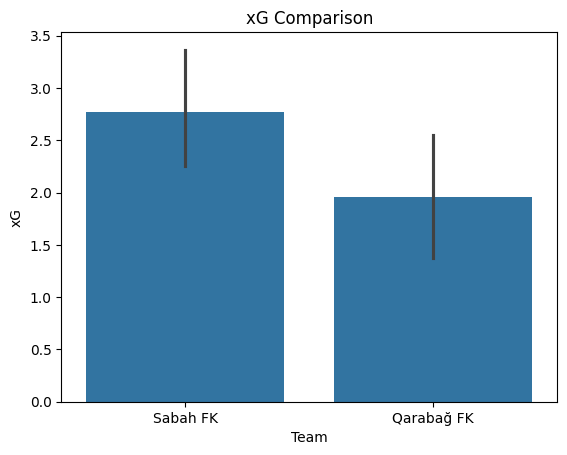

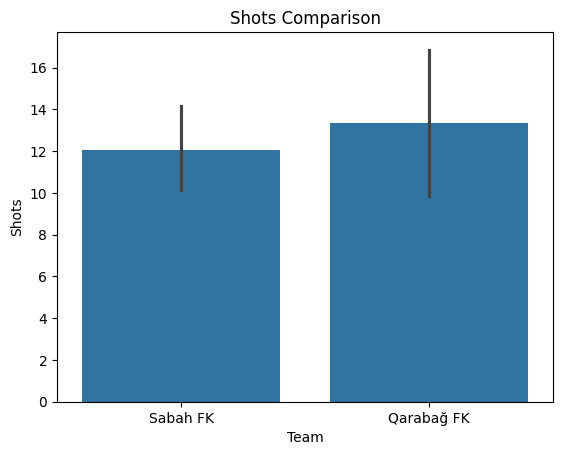

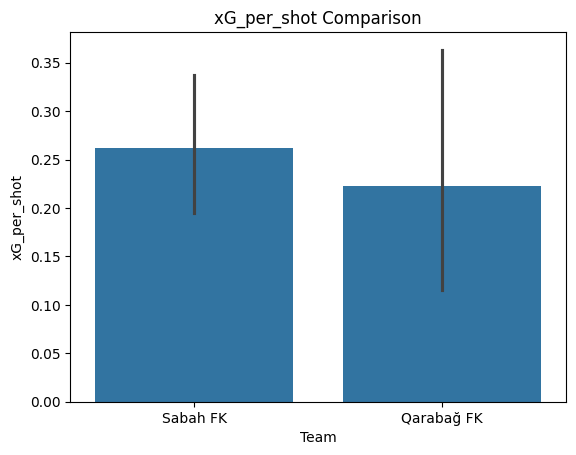

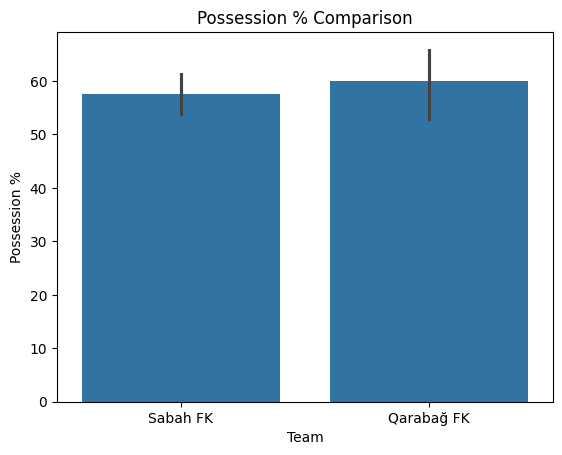

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

teams = ['Sabah FK', 'Qarabağ FK']
metrics = ['xG', 'Shots', 'xG_per_shot', 'Possession %']

for metric in metrics:
    sns.barplot(x='Team', y=metric, data=df[df['Team'].isin(teams)])
    plt.title(f"{metric} Comparison")
    plt.show()

# Win/Draw/Loss Sayları
Hər komandanın son oyunlarda Win, Draw və Loss sayları göstərilir.


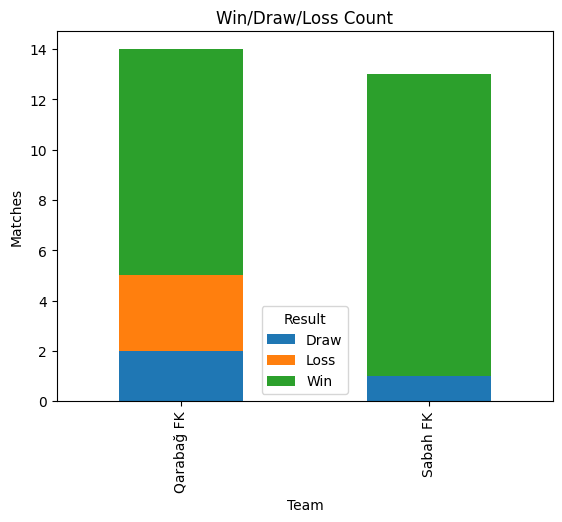

In [43]:
results = df[df['Team'].isin(teams)].groupby(['Team', 'Result']).size().unstack()
results.plot(kind='bar', stacked=True)
plt.title("Win/Draw/Loss Count")
plt.ylabel("Matches")
plt.show()

# xG və Shots Əlaqəsi
Hər komandanın qapıya doğru zərbə və xG arasındakı əlaqə scatter plot ilə göstərilir.

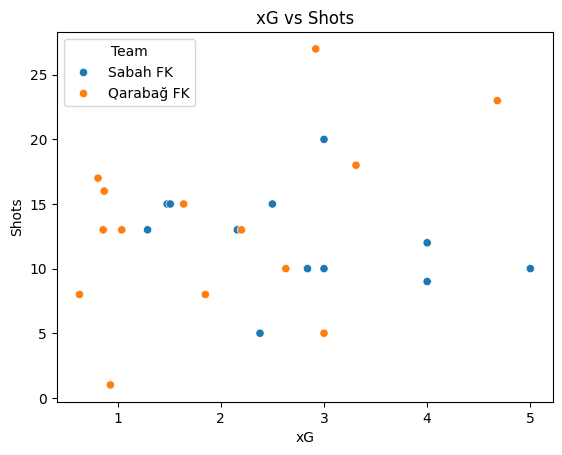

In [44]:
sns.scatterplot(x='xG', y='Shots', hue='Team', data=df[df['Team'].isin(teams)])
plt.title("xG vs Shots")
plt.show()

# Evdə vs Səfərdə xG per Shot
Komandaların ev və səfər oyunlarındakı hücum effektivliyi müqayisə olunur.

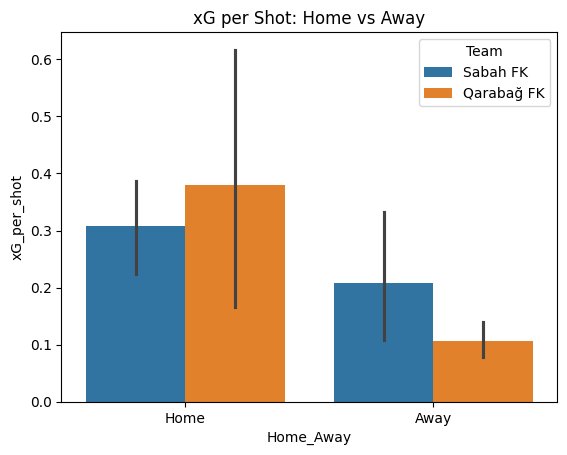

In [45]:
sns.barplot(x='Home_Away', y='xG_per_shot', hue='Team', data=df[df['Team'].isin(teams)])
plt.title("xG per Shot: Home vs Away")
plt.show()

# Ev/Səfər xG per Shot T-Test
Sabah FK üçün ev və səfər oyunlarında xG per Shot fərqi statistik olaraq yoxlanır.

In [46]:
from scipy.stats import ttest_ind

home = sabah[sabah['Home_Away'] == 'Home']['xG_per_shot']
away = sabah[sabah['Home_Away'] == 'Away']['xG_per_shot']

t_stat, p_val = ttest_ind(home, away)
print("t-statistic:", t_stat, "p-value:", p_val)

t-statistic: 1.2640045530646642 p-value: 0.23235699504658677


# Korrelyasiya Analizi
Seçilmiş metriklər arasındakı əlaqələr heatmap ilə göstərilir.

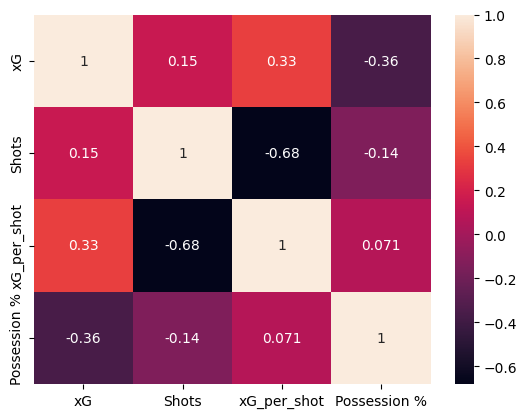

In [47]:
sns.heatmap(df[df['Team'].isin(teams)][['xG','Shots','xG_per_shot','Possession %']].corr(), annot=True)
plt.show()

# Qol Statistikası
Hər komandanın orta vurduğu, buraxdığı qollar və qol effektivliyi hesablanır.

In [48]:
def team_goals_stats(df, team_name):
    team = df[df['Team'] == team_name]
    avg_scored = team['Goals_Scored'].mean()
    avg_conceded = team['Goals_Conceded'].mean()
    goal_efficiency = (team['Goals_Scored'] / team['Shots']).mean()
    return avg_scored, avg_conceded, goal_efficiency

sabah_stats = team_goals_stats(df, 'Sabah FK')
qarabag_stats = team_goals_stats(df, 'Qarabağ FK')

print("Sabah FK:", sabah_stats)
print("Qarabağ FK:", qarabag_stats)

Sabah FK: (np.float64(3.1538461538461537), np.float64(0.8461538461538461), np.float64(0.2899079552925707))
Qarabağ FK: (np.float64(2.2142857142857144), np.float64(1.0714285714285714), np.float64(0.33983317407230457))


# Qol Müqayisəsi Qrafikləri
- Goals_Scored və Goals_Conceded bar chart-larla müqayisə edilir.

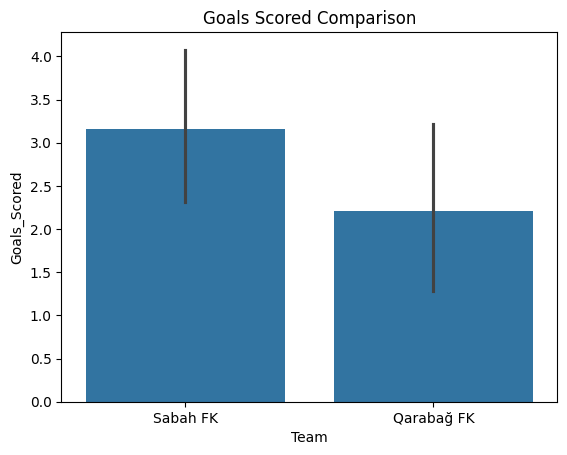

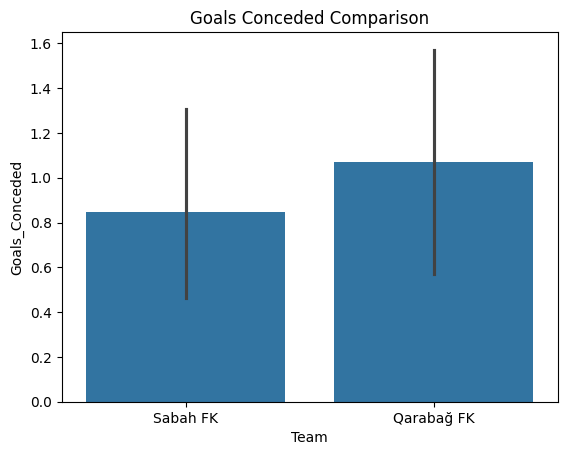

In [49]:
sns.barplot(x='Team', y='Goals_Scored', data=df[df['Team'].isin(teams)])
plt.title("Goals Scored Comparison")
plt.show()

sns.barplot(x='Team', y='Goals_Conceded', data=df[df['Team'].isin(teams)])
plt.title("Goals Conceded Comparison")
plt.show()

# Ev/Səfər Qolları
Komandaların ev və səfərdə vurduğu qollar px.bar ilə müqayisə olunur.

In [50]:
import plotly.express as px
px.bar(df[df['Team'].isin(teams)], x='Home_Away', y='Goals_Scored', color='Team', barmode='group')

## Nəticə və Analitik Yekun

Bu analiz Sabah FK və Qarabağ FK komandalarının son 13 oyunu əsasında aparılmışdır və nəticələr aşağıdakı əsas məqamları göstərir:

### 1. Qələbə Dinamikası
- Sabah FK: 12 qələbə, 1 heç-heçə, 0 məğlubiyyət  
- Qarabağ FK: 7 qələbə, 3 heç-heçə, 3 məğlubiyyət  

➡️ Sabah FK nəticələr baxımından açıq şəkildə daha dominant çıxış edir.

---

### 2. Hücum Yanaşması
- Sabah FK həm xG, həm də qapıya doğru zərbə sayına görə üstündür  
- Qarabağ FK bəzi oyunlarda yüksək xG yaratsa da, stabillik aşağıdır  

➡️ Sabah FK daha davamlı və təkrarlana bilən hücum strukturu qurur.

---

### 3. Effektivlik (xG vs Real Qol)
- Sabah FK yüksək xG-ni real qola çevirməyi bacarır  
- Qarabağ FK bəzi oyunlarda yüksək xG yaratsa da (məs: 2.92 xG → 0 qol), bu şansları realizə edə bilmir  

➡️ Qarabağ FK-də finishing problemi və ya qərarvermə zəifliyi müşahidə olunur.

---

### 4. Qapıya Doğru Zərbə vs Qol
- Sabah FK çox zərbə edir və bu zərbələrin böyük hissəsini qola çevirir  
- Qarabağ FK-də isə bəzən çox zərbə → az qol (inefficiency) halları var  

➡️ Sabah FK-də hücum keyfiyyəti və icra səviyyəsi daha yüksəkdir.

---

### 5. Müdafiə Performansı
- Sabah FK ümumilikdə daha az qol buraxır və daha balanslı görünür  
- Qarabağ FK-də bəzi oyunlarda müdafiə zəifliyi (2+ qol buraxma) var  

➡️ Sabah FK həm hücumda, həm müdafiədə daha stabil komandadır.

---

### 6. Ümumi Analitik Nəticə
Bu analiz göstərir ki:

- Sabah FK son 13 oyunda həm nəticə, həm hücum, həm də effektivlik baxımından daha üstündür  
- Qarabağ FK isə potensial olaraq güclü hücum yaratsa da, bunu stabil nəticəyə çevirə bilmir  

➡️ Yekun olaraq:
Sabah FK  **daha effektiv, daha stabil və nəticəyə oynayan komanda** kimi çıxış edir.